In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='Set2')

from dataloader_1 import (
    Sub, get_audio_encoding, get_video_encoding,
    get_multimodal_encoding, get_lowlevel_video_features,
)
from models_1 import LinearDeltaModel, MultimodalLinearDeltaModel
from visualizer_1 import Visualizer
import utils

## 1 · Build feature matrices

In [ ]:
# Audio-only (baseline)
X_audio_raw = get_audio_encoding(n_mfcc=15)
print("Audio shape:", X_audio_raw.shape)

# Video features (ViT-B/16)
X_video_raw = get_video_encoding(
    video_path="src/Film stimulus.mp4",
    cache_path="src/vit_b16_features.npy",
)
print("Video shape:", X_video_raw.shape)

Audio shape: (33642, 15)
[VideoEncoder] Loading cached embeddings from src/vit_b16_features.npy
Video shape: (9750, 768)


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


### 1.1 · Multimodal encoding with PCA *within* video

The critical fix: reduce video dimensionality **before** concatenation.
We try `video_pca=15`  and `video_pca=50`.

In [ ]:
X_multi_15, X_vid_15, X_aud_15 = get_multimodal_encoding(
    video_features=X_video_raw,
    n_mfcc=15,
    video_pca=30,      
)
print(f"\nVariant A (PCA=15): multi {X_multi_15.shape}")

X_multi_50, X_vid_50, X_aud_50 = get_multimodal_encoding(
    video_features=X_video_raw,
    n_mfcc=15,
    video_pca=50,
)
print(f"Variant B (PCA=50): multi {X_multi_50.shape}")

X_multi_raw, X_vid_raw, X_aud_raw = get_multimodal_encoding(
    video_features=X_video_raw,
    n_mfcc=15,
    video_pca=None,   
)
print(f"Variant C (no PCA): multi {X_multi_raw.shape}")

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)

Variant A (PCA=15): multi (9750, 45)


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
Variant B (PCA=50): multi (9750, 65)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 768) + audio (9750, 15) → multi (9750, 783)
Variant C (no PCA): multi (9750, 783)


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


## 2 · Load subject and configure hyperparameters

In [ ]:
SUB_ID   = '22'
DT       = 3        
COEF     = 2       
ALPHA_A  = 1000 

sub = Sub(SUB_ID)

## 3 · Audio-only baseline

In [5]:
audio_model = LinearDeltaModel(X_audio_raw, sub, DT, COEF, ALPHA_A)
audio_model.fit()
audio_model.predict()
audio_model.evaluate()
print(f"[Audio-only]  MSE_test = {audio_model.MSE_test:.4e}")

[Audio-only]  MSE_test = 2.8950e-05


## 4 · Video-only baseline

**Diagnostic step**: if video alone doesn't predict better than chance,
adding it to audio can only hurt.

In [ ]:
from sklearn.decomposition import PCA
from dataloader_1 import _resample_to_grid
from sklearn.preprocessing import StandardScaler

n_target = int(25.0 * 390.0)
t_target = np.linspace(0.0, 1.0, n_target)
vid_resampled = _resample_to_grid(X_video_raw, t_target)

for n_pc in [15, 50, 100]:
    pca = PCA(n_components=n_pc, random_state=42)
    vid_pca = StandardScaler().fit_transform(pca.fit_transform(vid_resampled))
    
    for alpha in [1e3, 1e4, 1e5]:
        vm = LinearDeltaModel(vid_pca, sub, DT, COEF, alpha)
        vm.fit(); vm.predict(); vm.evaluate()
        print(f"  Video-only PCA={n_pc:3d}  α={alpha:.0e}  MSE={vm.MSE_test:.4e}")
    print()

print(f"\n  Audio-only baseline for comparison:  MSE={audio_model.MSE_test:.4e}")

  Video-only PCA= 15  α=1e+03  MSE=2.8953e-05
  Video-only PCA= 15  α=1e+04  MSE=2.8956e-05
  Video-only PCA= 15  α=1e+05  MSE=2.8957e-05

  Video-only PCA= 50  α=1e+03  MSE=2.8977e-05
  Video-only PCA= 50  α=1e+04  MSE=2.8952e-05
  Video-only PCA= 50  α=1e+05  MSE=2.8957e-05

  Video-only PCA=100  α=1e+03  MSE=2.9135e-05
  Video-only PCA=100  α=1e+04  MSE=2.8955e-05
  Video-only PCA=100  α=1e+05  MSE=2.8957e-05


  Audio-only baseline for comparison:  MSE=2.8950e-05


## 5 · Multimodal model with banded ridge

Now we use `MultimodalLinearDeltaModel` **correctly**:
- Pass `alpha_video` and `alpha_audio` separately
- Pass `X_video` and `X_audio` for the banded penalty
- Set `pca_components=None` (PCA was already done in the dataloader)

In [ ]:
mm_15 = MultimodalLinearDeltaModel(
    vector_list  = X_multi_15,
    sub          = sub,
    dt           = DT,
    coef         = COEF,
    alpha_video  = 1e4,      
    alpha_audio  = 1e3,      
    X_video      = X_vid_15,
    X_audio      = X_aud_15,
    pca_components = None,   
)
mm_15.fit(); mm_15.predict(); mm_15.evaluate()
print(f"[Multimodal PCA=15]  MSE_test = {mm_15.MSE_test:.4e}")

mm_50 = MultimodalLinearDeltaModel(
    vector_list  = X_multi_50,
    sub          = sub,
    dt           = DT,
    coef         = COEF,
    alpha_video  = 1e5,     
    alpha_audio  = 1e3,
    X_video      = X_vid_50,
    X_audio      = X_aud_50,
    pca_components = None,
)
mm_50.fit(); mm_50.predict(); mm_50.evaluate()
print(f"[Multimodal PCA=50]  MSE_test = {mm_50.MSE_test:.4e}")

print(f"\n[Audio-only baseline]  MSE_test = {audio_model.MSE_test:.4e}")

[Multimodal PCA=15]  MSE_test = 2.9039e-05
[Multimodal PCA=50]  MSE_test = 2.9045e-05

[Audio-only baseline]  MSE_test = 2.8950e-05


## 6 · Banded ridge grid search

Find optimal (α_video, α_audio) for the PCA=15 variant.

In [23]:
alpha_v_grid = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5]
alpha_a_grid = [1e2, 5e2, 1e3, 5e3, 1e4]

print("Grid search for video_pca=15 variant:")
print("=" * 60)
best_av, best_aa, best_mse = MultimodalLinearDeltaModel.grid_search_alpha(
    vector_list    = X_multi_15,
    X_video        = X_vid_15,
    X_audio        = X_aud_15,
    sub            = sub,
    dt             = DT,
    coef           = COEF,
    alpha_video_grid = alpha_v_grid,
    alpha_audio_grid = alpha_a_grid,
)
print(f"\nAudio-only baseline: {audio_model.MSE_test:.4e}")
print(f"Best multimodal:     {best_mse:.4e}")
improvement = (audio_model.MSE_test - best_mse) / audio_model.MSE_test * 100
print(f"Improvement:         {improvement:+.2f}%")

Grid search for video_pca=15 variant:
  [1/35] α_v=1e+02  α_a=1e+02  MSE=2.986e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=2.946e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=2.936e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=2.930e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=2.929e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=2.947e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=2.913e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=2.904e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=2.897e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=2.896e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=2.944e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=2.911e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=2.902e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=2.895e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=2.894e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=2.943e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=2.912e-05
  [18/35] α_v=5e+03  α_a=1e+03  MSE=2.903e-05
  [19/35] α_v=5e+03  α_a=5e+03  MSE=2.896e-05
  [20/35] α_v=5e+03  α_a=1e+04  MSE=2.895e-05
  [21/35] α_v=1e+04  α_a=1e+02  MSE=2.943e-05
  [22

## 7 · Train best multimodal model

In [ ]:
mm_best = MultimodalLinearDeltaModel(
    vector_list    = X_multi_15,
    sub            = sub,
    dt             = DT,
    coef           = COEF,
    alpha_video    = best_av,
    alpha_audio    = best_aa,
    X_video        = X_vid_15,
    X_audio        = X_aud_15,
    pca_components = None,
)
mm_best.fit(); mm_best.predict(); mm_best.evaluate()

contrib = mm_best.modality_mse()
print("Per-modality MSE:")
for name, mse in contrib.items():
    print(f"  {name:12s}  MSE = {mse:.4e}")

Per-modality MSE:
  video         MSE = 2.8953e-05
  audio         MSE = 2.8963e-05
  multimodal    MSE = 2.8958e-05


## 8 · Δt sweep — audio vs multimodal (fixed)

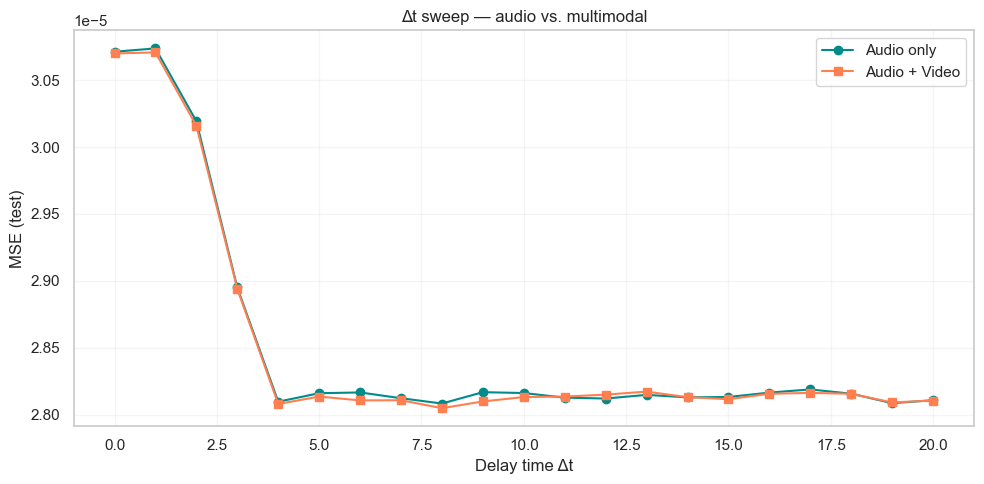

Best Δt audio:      8s  (MSE=2.8082e-05)
Best Δt multimodal: 8s  (MSE=2.8047e-05)


In [ ]:
t_vals = np.arange(0, 21, 1)  

mse_audio = []
mse_multi = []

for dt_val in t_vals:
    m = LinearDeltaModel(X_audio_raw, sub, dt_val, COEF, ALPHA_A)
    m.fit(); m.predict(); m.evaluate()
    mse_audio.append(m.MSE_test)

    m2 = MultimodalLinearDeltaModel(
        vector_list    = X_multi_15,
        sub            = sub,
        dt             = dt_val,
        coef           = COEF,
        alpha_video    = best_av,
        alpha_audio    = best_aa,
        X_video        = X_vid_15,
        X_audio        = X_aud_15,
        pca_components = None,
    )
    m2.fit(); m2.predict(); m2.evaluate()
    mse_multi.append(m2.MSE_test)

plt.figure(figsize=(10, 5))
plt.plot(t_vals, mse_audio, marker='o', color='darkcyan',  label='Audio only')
plt.plot(t_vals, mse_multi, marker='s', color='coral',     label='Audio + Video')
plt.xlabel('Delay time Δt')
plt.ylabel('MSE (test)')
plt.legend()
plt.title('Δt sweep — audio vs. multimodal')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('mse_dt_multimodal_fixed.pdf', bbox_inches='tight')
plt.show()


best_dt_a = t_vals[np.argmin(mse_audio)]
best_dt_m = t_vals[np.argmin(mse_multi)]
print(f"Best Δt audio:      {best_dt_a}s  (MSE={min(mse_audio):.4e})")
print(f"Best Δt multimodal: {best_dt_m}s  (MSE={min(mse_multi):.4e})")

## 9 · Multi-subject comparison

Sub 07:  audio=2.4968e-05  A+V=2.4987e-05  Δ=-0.08%
Sub 22:  audio=2.8950e-05  A+V=2.8940e-05  Δ=+0.03%
Sub 31:  audio=3.2457e-05  A+V=3.2481e-05  Δ=-0.07%


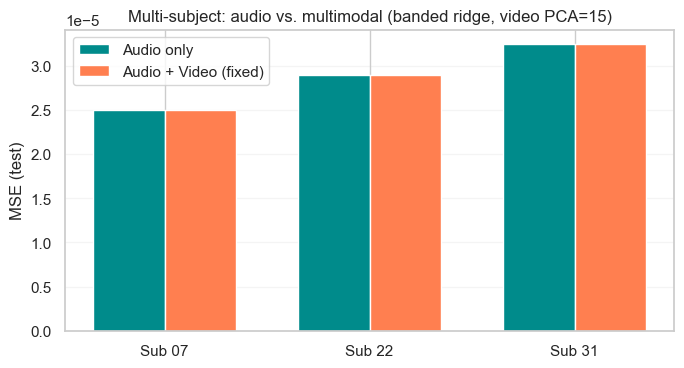

In [ ]:
subjects = ['07', '22', '31']
results = {}

for sid in subjects:
    s = Sub(sid)

    ma = LinearDeltaModel(X_audio_raw, s, DT, COEF, ALPHA_A)
    ma.fit(); ma.predict(); ma.evaluate()

    mm = MultimodalLinearDeltaModel(
        vector_list    = X_multi_15,
        sub            = s,
        dt             = DT,
        coef           = COEF,
        alpha_video    = best_av,
        alpha_audio    = best_aa,
        X_video        = X_vid_15,
        X_audio        = X_aud_15,
        pca_components = None,
    )
    mm.fit(); mm.predict(); mm.evaluate()

    results[sid] = {
        'audio':      ma.MSE_test,
        'multimodal': mm.MSE_test,
    }
    delta = (ma.MSE_test - mm.MSE_test) / ma.MSE_test * 100
    print(f"Sub {sid}:  audio={ma.MSE_test:.4e}  A+V={mm.MSE_test:.4e}  Δ={delta:+.2f}%")

x = np.arange(len(subjects))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, [results[s]['audio']      for s in subjects], w,
       label='Audio only', color='darkcyan')
ax.bar(x + w/2, [results[s]['multimodal'] for s in subjects], w,
       label='Audio + Video (fixed)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([f'Sub {s}' for s in subjects])
ax.set_ylabel('MSE (test)')
ax.legend()
ax.grid(axis='y', alpha=0.2)
ax.set_title('Multi-subject: audio vs. multimodal (banded ridge, video PCA=15)')
plt.tight_layout()
plt.savefig('mse_subjects_multimodal_fixed.pdf', bbox_inches='tight')
plt.show()

In [ ]:
subjects = ['07', '22', '31']
alpha_v_grid = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5]
alpha_a_grid = [1e2, 5e2, 1e3, 5e3, 1e4]
t_vals = np.arange(0, 21, 1)

results = {}

for sid in subjects:
    s = Sub(sid)
    print(f"\n{'='*60}")
    print(f"Subject {sid}")
    print(f"{'='*60}")

    # 1. Grid search α_v, α_a при DT=3
    print("\n--- Step 1: grid search α ---")
    av, aa, _ = MultimodalLinearDeltaModel.grid_search_alpha(
        X_multi_15, X_vid_15, X_aud_15, s, 3, COEF,
        alpha_v_grid, alpha_a_grid,
    )

    # 2. Sweep Δt с найденными α
    print(f"\n--- Step 2: Δt sweep (α_v={av:.0e}, α_a={aa:.0e}) ---")
    best_dt_a, best_mse_a = None, np.inf
    best_dt_m, best_mse_m = None, np.inf

    for dt_val in t_vals:
        ma = LinearDeltaModel(X_audio_raw, s, dt_val, COEF, ALPHA_A)
        ma.fit(); ma.predict(); ma.evaluate()
        if ma.MSE_test < best_mse_a:
            best_mse_a = ma.MSE_test
            best_dt_a = dt_val

        mm = MultimodalLinearDeltaModel(
            vector_list=X_multi_15, sub=s, dt=dt_val, coef=COEF,
            alpha_video=av, alpha_audio=aa,
            X_video=X_vid_15, X_audio=X_aud_15, pca_components=None,
        )
        mm.fit(); mm.predict(); mm.evaluate()
        if mm.MSE_test < best_mse_m:
            best_mse_m = mm.MSE_test
            best_dt_m = dt_val

    delta = (best_mse_a - best_mse_m) / best_mse_a * 100
    results[sid] = {
        'av': av, 'aa': aa,
        'best_dt_a': best_dt_a, 'best_dt_m': best_dt_m,
        'mse_a': best_mse_a, 'mse_m': best_mse_m,
    }

    print(f"\n  α_v={av:.0e}  α_a={aa:.0e}")
    print(f"  Audio:  best Δt={best_dt_a}s  MSE={best_mse_a:.4e}")
    print(f"  Multi:  best Δt={best_dt_m}s  MSE={best_mse_m:.4e}")
    print(f"  Improvement: {delta:+.3f}%")


Subject 07

--- Step 1: grid search α ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=2.591e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=2.557e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=2.549e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=2.544e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=2.544e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=2.539e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=2.514e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=2.508e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=2.504e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=2.505e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=2.531e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=2.508e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=2.502e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=2.499e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=2.499e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=2.525e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=2.503e-05
  [18/35] α_v=5e+03  α_a=1e+03  MSE=2.498e-05
  [19/35] α_v=5e+03  α_a=5e+03  MSE=2.495e-05
  [20/35] α_v=5e+03  α_a=1e+04  MSE=2.495e-05
  [21/35] α_v=1e+04  α_a=1e+02  MSE=2.524e-05



Subject 09

--- Step 1: PCA sweep ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  PCA=  5  MSE=2.6144e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  PCA= 10  MSE=2.6148e-05


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  PCA= 30  MSE=2.6200e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  PCA= 50  MSE=2.6208e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  PCA=100  MSE=2.6518e-05
  → Best PCA=5 for Sub 09


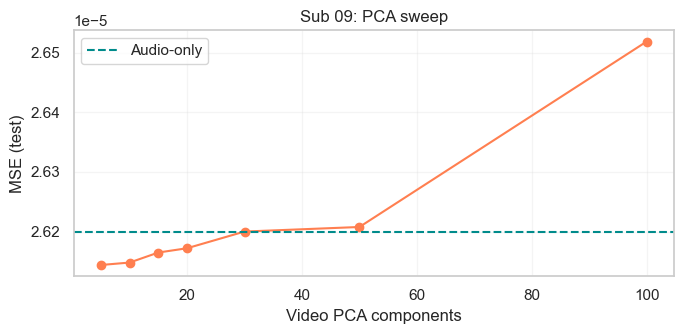

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)

--- Step 2: grid search α (PCA=5) ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=2.653e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=2.624e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=2.617e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=2.615e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=2.615e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=2.650e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=2.622e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=2.616e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=2.614e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=2.614e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=2.649e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=2.622e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=2.616e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=2.614e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=2.614e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=2.649e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=2.622e-05
 

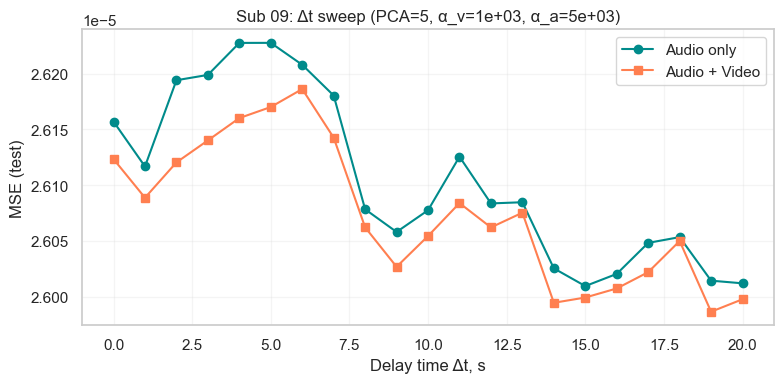


  Summary Sub 09:
    PCA=5  α_v=1e+03  α_a=5e+03
    Audio:  Δt=15s  MSE=2.6010e-05
    Multi:  Δt=19s  MSE=2.5987e-05
    Improvement: +0.088%

Subject 11

--- Step 1: PCA sweep ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  PCA=  5  MSE=2.3463e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  PCA= 10  MSE=2.3458e-05


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  PCA= 30  MSE=2.3488e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  PCA= 50  MSE=2.3597e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  PCA=100  MSE=2.3733e-05
  → Best PCA=10 for Sub 11


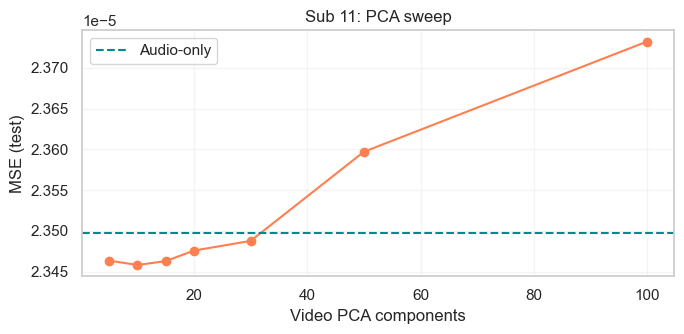

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)

--- Step 2: grid search α (PCA=10) ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=2.393e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=2.362e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=2.355e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=2.351e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=2.351e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=2.388e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=2.358e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=2.351e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=2.346e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=2.346e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=2.388e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=2.359e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=2.351e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=2.346e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=2.346e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=2.389e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=2.360e-0

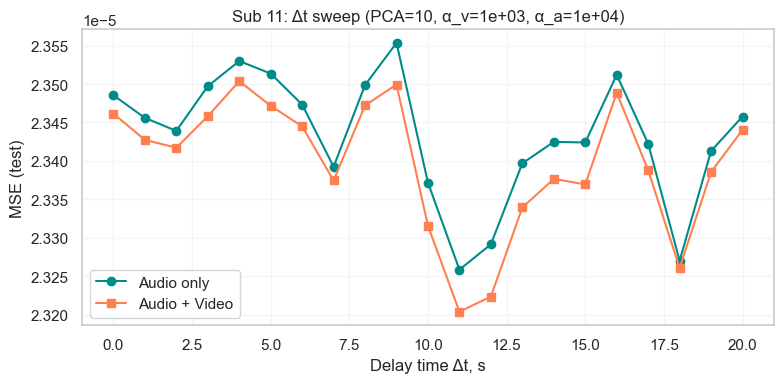


  Summary Sub 11:
    PCA=10  α_v=1e+03  α_a=1e+04
    Audio:  Δt=11s  MSE=2.3258e-05
    Multi:  Δt=11s  MSE=2.3204e-05
    Improvement: +0.235%

Subject 13

--- Step 1: PCA sweep ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  PCA=  5  MSE=3.3212e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  PCA= 10  MSE=3.3214e-05


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  PCA= 30  MSE=3.3253e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  PCA= 50  MSE=3.3305e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  PCA=100  MSE=3.3465e-05
  → Best PCA=5 for Sub 13


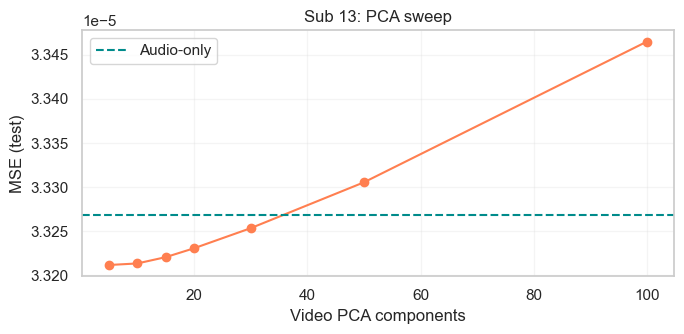

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)

--- Step 2: grid search α (PCA=5) ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=3.382e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=3.342e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=3.332e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=3.323e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=3.323e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=3.379e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=3.340e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=3.330e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=3.322e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=3.321e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=3.379e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=3.340e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=3.330e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=3.322e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=3.321e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=3.378e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=3.340e-05
 

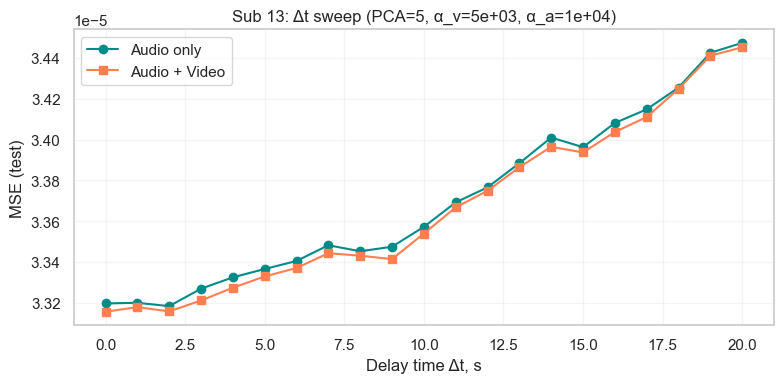


  Summary Sub 13:
    PCA=5  α_v=5e+03  α_a=1e+04
    Audio:  Δt=2s  MSE=3.3183e-05
    Multi:  Δt=0s  MSE=3.3156e-05
    Improvement: +0.082%

Subject 14

--- Step 1: PCA sweep ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  PCA=  5  MSE=4.1765e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  PCA= 10  MSE=4.1783e-05


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  PCA= 30  MSE=4.1902e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  PCA= 50  MSE=4.1932e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  PCA=100  MSE=4.2312e-05
  → Best PCA=5 for Sub 14


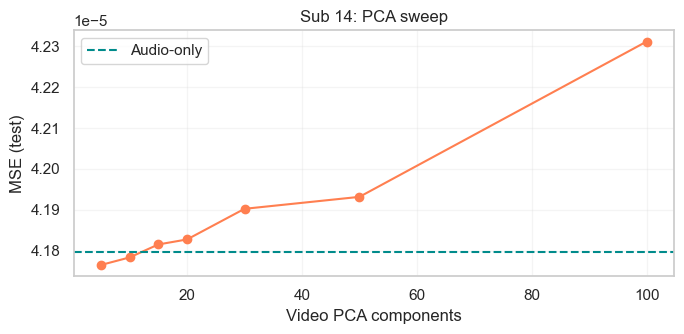

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)

--- Step 2: grid search α (PCA=5) ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=4.271e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=4.209e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=4.192e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=4.181e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=4.181e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=4.263e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=4.203e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=4.188e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=4.177e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=4.177e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=4.260e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=4.202e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=4.187e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=4.177e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=4.176e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=4.258e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=4.201e-05
 

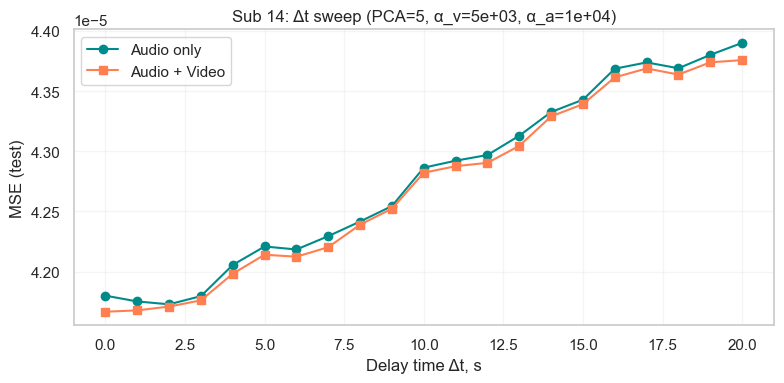


  Summary Sub 14:
    PCA=5  α_v=5e+03  α_a=1e+04
    Audio:  Δt=2s  MSE=4.1727e-05
    Multi:  Δt=0s  MSE=4.1666e-05
    Improvement: +0.148%

Subject 15

--- Step 1: PCA sweep ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  PCA=  5  MSE=4.0878e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  PCA= 10  MSE=4.0884e-05


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  PCA= 30  MSE=4.0917e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  PCA= 50  MSE=4.0939e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  PCA=100  MSE=4.1245e-05
  → Best PCA=5 for Sub 15


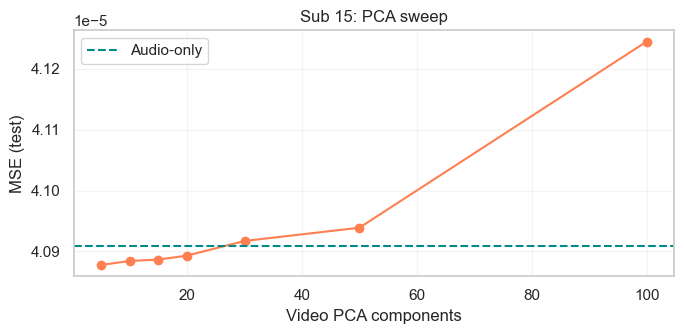

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)

--- Step 2: grid search α (PCA=5) ---
  [1/35] α_v=1e+02  α_a=1e+02  MSE=4.164e-05
  [2/35] α_v=1e+02  α_a=5e+02  MSE=4.111e-05
  [3/35] α_v=1e+02  α_a=1e+03  MSE=4.098e-05
  [4/35] α_v=1e+02  α_a=5e+03  MSE=4.090e-05
  [5/35] α_v=1e+02  α_a=1e+04  MSE=4.090e-05
  [6/35] α_v=5e+02  α_a=1e+02  MSE=4.158e-05
  [7/35] α_v=5e+02  α_a=5e+02  MSE=4.108e-05
  [8/35] α_v=5e+02  α_a=1e+03  MSE=4.096e-05
  [9/35] α_v=5e+02  α_a=5e+03  MSE=4.088e-05
  [10/35] α_v=5e+02  α_a=1e+04  MSE=4.088e-05
  [11/35] α_v=1e+03  α_a=1e+02  MSE=4.157e-05
  [12/35] α_v=1e+03  α_a=5e+02  MSE=4.107e-05
  [13/35] α_v=1e+03  α_a=1e+03  MSE=4.095e-05
  [14/35] α_v=1e+03  α_a=5e+03  MSE=4.088e-05
  [15/35] α_v=1e+03  α_a=1e+04  MSE=4.088e-05
  [16/35] α_v=5e+03  α_a=1e+02  MSE=4.155e-05
  [17/35] α_v=5e+03  α_a=5e+02  MSE=4.107e-05
 

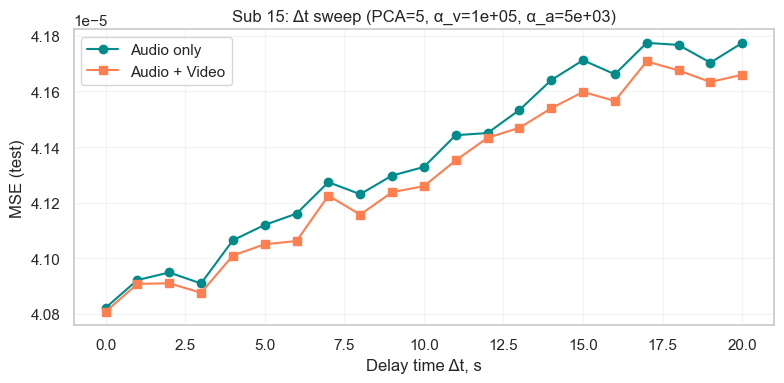


  Summary Sub 15:
    PCA=5  α_v=1e+05  α_a=5e+03
    Audio:  Δt=0s  MSE=4.0821e-05
    Multi:  Δt=0s  MSE=4.0807e-05
    Improvement: +0.034%

  Sub   PCA      α_v      α_a  Δt_a  Δt_m        MSE_a        MSE_m       Δ%
----------------------------------------------------------------------
   09     5    1e+03    5e+03    15    19   2.6010e-05   2.5987e-05  +0.088%
   11    10    1e+03    1e+04    11    11   2.3258e-05   2.3204e-05  +0.235%
   13     5    5e+03    1e+04     2     0   3.3183e-05   3.3156e-05  +0.082%
   14     5    5e+03    1e+04     2     0   4.1727e-05   4.1666e-05  +0.148%
   15     5    1e+05    5e+03     0     0   4.0821e-05   4.0807e-05  +0.034%


In [ ]:
subjects = ['09', '11', '13', '14', '15']
alpha_v_grid = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5]
alpha_a_grid = [1e2, 5e2, 1e3, 5e3, 1e4]
pca_dims = [5, 10, 15, 20, 30, 50, 100]
t_vals = np.arange(0, 21, 1)

results = {}

for sid in subjects:
    s = Sub(sid)
    print(f"\n{'='*60}")
    print(f"Subject {sid}")
    print(f"{'='*60}")

    # 1. PCA sweep — найти лучшее число компонент
    print("\n--- Step 1: PCA sweep ---")
    
    # Сначала audio baseline при DT=3 для сравнения
    ma_base = LinearDeltaModel(X_audio_raw, s, 3, COEF, ALPHA_A)
    ma_base.fit(); ma_base.predict(); ma_base.evaluate()
    baseline_mse = ma_base.MSE_test
    
    best_pca, best_pca_mse = None, np.inf
    mse_by_pca = []
    
    for n_pc in pca_dims:
        X_m, X_v, X_a = get_multimodal_encoding(
            video_features=X_video_raw, n_mfcc=15, video_pca=n_pc,
        )
        m = MultimodalLinearDeltaModel(
            vector_list=X_m, sub=s, dt=3, coef=COEF,
            alpha_video=1e3, alpha_audio=1e4,
            X_video=X_v, X_audio=X_a, pca_components=None,
        )
        m.fit(); m.predict(); m.evaluate()
        mse_by_pca.append(m.MSE_test)
        print(f"  PCA={n_pc:3d}  MSE={m.MSE_test:.4e}")
        if m.MSE_test < best_pca_mse:
            best_pca_mse = m.MSE_test
            best_pca = n_pc

    print(f"  → Best PCA={best_pca} for Sub {sid}")

    # График PCA sweep
    plt.figure(figsize=(7, 3.5))
    plt.plot(pca_dims, mse_by_pca, marker='o', color='coral')
    plt.axhline(baseline_mse, color='darkcyan', linestyle='--', label='Audio-only')
    plt.xlabel('Video PCA components')
    plt.ylabel('MSE (test)')
    plt.title(f'Sub {sid}: PCA sweep')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'pca_sweep_sub{sid}.pdf', bbox_inches='tight')
    plt.show()

    # Построить мультимодальные признаки с лучшим PCA
    X_multi_best, X_vid_best, X_aud_best = get_multimodal_encoding(
        video_features=X_video_raw, n_mfcc=15, video_pca=best_pca,
    )

    # 2. Grid search α при лучшем PCA
    print(f"\n--- Step 2: grid search α (PCA={best_pca}) ---")
    av, aa, _ = MultimodalLinearDeltaModel.grid_search_alpha(
        X_multi_best, X_vid_best, X_aud_best, s, 3, COEF,
        alpha_v_grid, alpha_a_grid,
    )

    # 3. Sweep Δt
    print(f"\n--- Step 3: Δt sweep (PCA={best_pca}, α_v={av:.0e}, α_a={aa:.0e}) ---")
    best_dt_a, best_mse_a = None, np.inf
    best_dt_m, best_mse_m = None, np.inf
    mse_audio_dt = []
    mse_multi_dt = []

    for dt_val in t_vals:
        ma = LinearDeltaModel(X_audio_raw, s, dt_val, COEF, ALPHA_A)
        ma.fit(); ma.predict(); ma.evaluate()
        mse_audio_dt.append(ma.MSE_test)
        if ma.MSE_test < best_mse_a:
            best_mse_a = ma.MSE_test
            best_dt_a = dt_val

        mm = MultimodalLinearDeltaModel(
            vector_list=X_multi_best, sub=s, dt=dt_val, coef=COEF,
            alpha_video=av, alpha_audio=aa,
            X_video=X_vid_best, X_audio=X_aud_best, pca_components=None,
        )
        mm.fit(); mm.predict(); mm.evaluate()
        mse_multi_dt.append(mm.MSE_test)
        if mm.MSE_test < best_mse_m:
            best_mse_m = mm.MSE_test
            best_dt_m = dt_val

    # График Δt sweep
    plt.figure(figsize=(8, 4))
    plt.plot(t_vals, mse_audio_dt, marker='o', color='darkcyan', label='Audio only')
    plt.plot(t_vals, mse_multi_dt, marker='s', color='coral', label='Audio + Video')
    plt.xlabel('Delay time Δt, s')
    plt.ylabel('MSE (test)')
    plt.title(f'Sub {sid}: Δt sweep (PCA={best_pca}, α_v={av:.0e}, α_a={aa:.0e})')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'dt_sweep_sub{sid}.pdf', bbox_inches='tight')
    plt.show()

    delta = (best_mse_a - best_mse_m) / best_mse_a * 100
    results[sid] = {
        'best_pca': best_pca, 'av': av, 'aa': aa,
        'best_dt_a': best_dt_a, 'best_dt_m': best_dt_m,
        'mse_a': best_mse_a, 'mse_m': best_mse_m,
        'delta': delta,
    }

    print(f"\n  Summary Sub {sid}:")
    print(f"    PCA={best_pca}  α_v={av:.0e}  α_a={aa:.0e}")
    print(f"    Audio:  Δt={best_dt_a}s  MSE={best_mse_a:.4e}")
    print(f"    Multi:  Δt={best_dt_m}s  MSE={best_mse_m:.4e}")
    print(f"    Improvement: {delta:+.3f}%")

print(f"\n{'='*60}")
print(f"{'Sub':>5s} {'PCA':>5s} {'α_v':>8s} {'α_a':>8s} "
      f"{'Δt_a':>5s} {'Δt_m':>5s} {'MSE_a':>12s} {'MSE_m':>12s} {'Δ%':>8s}")
print("-" * 70)
for sid in subjects:
    r = results[sid]
    print(f"  {sid:>3s} {r['best_pca']:>5d} {r['av']:>8.0e} {r['aa']:>8.0e} "
          f"{r['best_dt_a']:>5d} {r['best_dt_m']:>5d} "
          f"{r['mse_a']:>12.4e} {r['mse_m']:>12.4e} {r['delta']:>+7.3f}%")


Subject 04

--- Step 1: joint PCA + α search ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  [1/12] α_v=1e+02  α_a=1e+02  MSE=4.614e-05
  [2/12] α_v=1e+02  α_a=1e+03  MSE=4.524e-05
  [3/12] α_v=1e+02  α_a=1e+04  MSE=4.512e-05
  [4/12] α_v=1e+03  α_a=1e+02  MSE=4.599e-05
  [5/12] α_v=1e+03  α_a=1e+03  MSE=4.515e-05
  [6/12] α_v=1e+03  α_a=1e+04  MSE=4.504e-05
  [7/12] α_v=1e+04  α_a=1e+02  MSE=4.597e-05
  [8/12] α_v=1e+04  α_a=1e+03  MSE=4.516e-05
  [9/12] α_v=1e+04  α_a=1e+04  MSE=4.504e-05
  [10/12] α_v=1e+05  α_a=1e+02  MSE=4.597e-05
  [11/12] α_v=1e+05  α_a=1e+03  MSE=4.516e-05
  [12/12] α_v=1e+05  α_a=1e+04  MSE=4.505e-05

→ Best: α_video=1e+03  α_audio=1e+04  MSE=4.504e-05
  PCA= 10  α_v=1e+03  α_a=1e+04  MSE=4.5041e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 20 components (62.1% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 20) + audio (9750, 15) → multi (9750, 35)
  [1/12] α_v=1e+02  α_a=1e+02  MSE=4.672e-05
  [2/12] α_v=1e+02  α_a=1e+03  MSE=4.572e-05
  [3/12] α_v=1e+02  α_a=1e+04  MSE=4.559e-05
  [4/12] α_v=1e+03  α_a=1e+02  MSE=4.605e-05
  [5/12] α_v=1e+03  α_a=1e+03  MSE=4.519e-05
  [6/12] α_v=1e+03  α_a=1e+04  MSE=4.508e-05
  [7/12] α_v=1e+04  α_a=1e+02  MSE=4.597e-05
  [8/12] α_v=1e+04  α_a=1e+03  MSE=4.516e-05
  [9/12] α_v=1e+04  α_a=1e+04  MSE=4.505e-05
  [10/12] α_v=1e+05  α_a=1e+02  MSE=4.597e-05
  [11/12] α_v=1e+05  α_a=1e+03  MSE=4.516e-05
  [12/12] α_v=1e+05  α_a=1e+04  MSE=4.505e-05

→ Best: α_video=1e+05  α_audio=1e+04  MSE=4.505e-05
  PCA= 20  α_v=1e+05  α_a=1e+04  MSE=4.5047e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  [1/12] α_v=1e+02  α_a=1e+02  MSE=4.758e-05
  [2/12] α_v=1e+02  α_a=1e+03  MSE=4.641e-05
  [3/12] α_v=1e+02  α_a=1e+04  MSE=4.624e-05
  [4/12] α_v=1e+03  α_a=1e+02  MSE=4.612e-05
  [5/12] α_v=1e+03  α_a=1e+03  MSE=4.523e-05
  [6/12] α_v=1e+03  α_a=1e+04  MSE=4.511e-05
  [7/12] α_v=1e+04  α_a=1e+02  MSE=4.598e-05
  [8/12] α_v=1e+04  α_a=1e+03  MSE=4.516e-05
  [9/12] α_v=1e+04  α_a=1e+04  MSE=4.505e-05
  [10/12] α_v=1e+05  α_a=1e+02  MSE=4.597e-05
  [11/12] α_v=1e+05  α_a=1e+03  MSE=4.516e-05
  [12/12] α_v=1e+05  α_a=1e+04  MSE=4.505e-05

→ Best: α_video=1e+05  α_audio=1e+04  MSE=4.505e-05
  PCA= 30  α_v=1e+05  α_a=1e+04  MSE=4.5047e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  [1/12] α_v=1e+02  α_a=1e+02  MSE=5.006e-05
  [2/12] α_v=1e+02  α_a=1e+03  MSE=4.875e-05
  [3/12] α_v=1e+02  α_a=1e+04  MSE=4.858e-05
  [4/12] α_v=1e+03  α_a=1e+02  MSE=4.620e-05
  [5/12] α_v=1e+03  α_a=1e+03  MSE=4.528e-05
  [6/12] α_v=1e+03  α_a=1e+04  MSE=4.515e-05
  [7/12] α_v=1e+04  α_a=1e+02  MSE=4.598e-05
  [8/12] α_v=1e+04  α_a=1e+03  MSE=4.516e-05
  [9/12] α_v=1e+04  α_a=1e+04  MSE=4.504e-05
  [10/12] α_v=1e+05  α_a=1e+02  MSE=4.597e-05
  [11/12] α_v=1e+05  α_a=1e+03  MSE=4.516e-05
  [12/12] α_v=1e+05  α_a=1e+04  MSE=4.505e-05

→ Best: α_video=1e+04  α_audio=1e+04  MSE=4.504e-05
  PCA= 50  α_v=1e+04  α_a=1e+04  MSE=4.5043e-05
  → Best: PCA=10  α_v=1e+03  α_a=1e+04


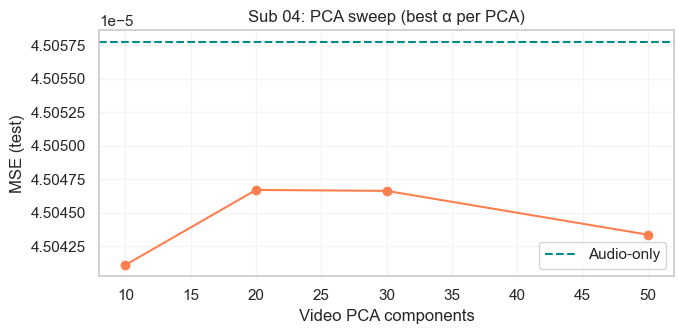


--- Step 2: Δt sweep (PCA=10, α_v=1e+03, α_a=1e+04) ---


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)


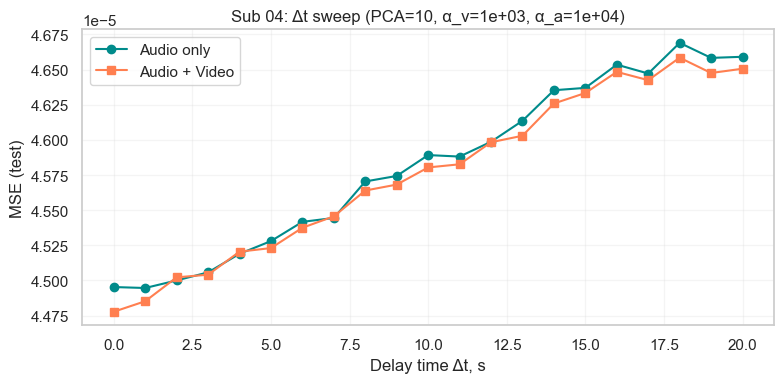


  Summary Sub 04:
    PCA=10  α_v=1e+03  α_a=1e+04
    Audio:  Δt=1s  MSE=4.4947e-05
    Multi:  Δt=0s  MSE=4.4778e-05
    Improvement: +0.375%

  Sub   PCA      α_v      α_a  Δt_a  Δt_m        MSE_a        MSE_m       Δ%
----------------------------------------------------------------------
   04    10    1e+03    1e+04     1     0   4.4947e-05   4.4778e-05  +0.375%


In [ ]:
subjects = ['04']
pca_dims = [10, 20, 30, 50]
alpha_v_grid = [1e2, 1e3, 1e4, 1e5]
alpha_a_grid = [1e2, 1e3, 1e4]
t_vals = np.arange(0, 21, 1)

results = {}

for sid in subjects:
    s = Sub(sid)
    print(f"\n{'='*60}")
    print(f"Subject {sid}")
    print(f"{'='*60}")

    # Audio baseline
    ma_base = LinearDeltaModel(X_audio_raw, s, 3, COEF, ALPHA_A)
    ma_base.fit(); ma_base.predict(); ma_base.evaluate()
    baseline_mse = ma_base.MSE_test

    # 1. Совместный PCA + α sweep
    print("\n--- Step 1: joint PCA + α search ---")
    best_pca, best_av, best_aa, best_pca_mse = None, None, None, np.inf
    mse_by_pca = []

    for n_pc in pca_dims:
        X_m, X_v, X_a = get_multimodal_encoding(
            video_features=X_video_raw, n_mfcc=15, video_pca=n_pc,
        )
        av, aa, mse = MultimodalLinearDeltaModel.grid_search_alpha(
            X_m, X_v, X_a, s, 3, COEF,
            alpha_v_grid, alpha_a_grid,
        )
        mse_by_pca.append(mse)
        print(f"  PCA={n_pc:3d}  α_v={av:.0e}  α_a={aa:.0e}  MSE={mse:.4e}")
        if mse < best_pca_mse:
            best_pca_mse = mse
            best_pca, best_av, best_aa = n_pc, av, aa

    print(f"  → Best: PCA={best_pca}  α_v={best_av:.0e}  α_a={best_aa:.0e}")

    # PCA график
    plt.figure(figsize=(7, 3.5))
    plt.plot(pca_dims, mse_by_pca, marker='o', color='coral')
    plt.axhline(baseline_mse, color='darkcyan', linestyle='--', label='Audio-only')
    plt.xlabel('Video PCA components')
    plt.ylabel('MSE (test)')
    plt.title(f'Sub {sid}: PCA sweep (best α per PCA)')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'pca_sweep_sub{sid}.pdf', bbox_inches='tight')
    plt.show()

    # 2. Δt sweep с лучшими PCA и α
    print(f"\n--- Step 2: Δt sweep (PCA={best_pca}, α_v={best_av:.0e}, α_a={best_aa:.0e}) ---")
    X_multi_best, X_vid_best, X_aud_best = get_multimodal_encoding(
        video_features=X_video_raw, n_mfcc=15, video_pca=best_pca,
    )

    best_dt_a, best_mse_a = None, np.inf
    best_dt_m, best_mse_m = None, np.inf
    mse_audio_dt = []
    mse_multi_dt = []

    for dt_val in t_vals:
        ma = LinearDeltaModel(X_audio_raw, s, dt_val, COEF, ALPHA_A)
        ma.fit(); ma.predict(); ma.evaluate()
        mse_audio_dt.append(ma.MSE_test)
        if ma.MSE_test < best_mse_a:
            best_mse_a = ma.MSE_test
            best_dt_a = dt_val

        mm = MultimodalLinearDeltaModel(
            vector_list=X_multi_best, sub=s, dt=dt_val, coef=COEF,
            alpha_video=best_av, alpha_audio=best_aa,
            X_video=X_vid_best, X_audio=X_aud_best, pca_components=None,
        )
        mm.fit(); mm.predict(); mm.evaluate()
        mse_multi_dt.append(mm.MSE_test)
        if mm.MSE_test < best_mse_m:
            best_mse_m = mm.MSE_test
            best_dt_m = dt_val

    # Δt график
    plt.figure(figsize=(8, 4))
    plt.plot(t_vals, mse_audio_dt, marker='o', color='darkcyan', label='Audio only')
    plt.plot(t_vals, mse_multi_dt, marker='s', color='coral', label='Audio + Video')
    plt.xlabel('Delay time Δt, s')
    plt.ylabel('MSE (test)')
    plt.title(f'Sub {sid}: Δt sweep (PCA={best_pca}, α_v={best_av:.0e}, α_a={best_aa:.0e})')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'dt_sweep_sub{sid}.pdf', bbox_inches='tight')
    plt.show()

    delta = (best_mse_a - best_mse_m) / best_mse_a * 100
    results[sid] = {
        'best_pca': best_pca, 'av': best_av, 'aa': best_aa,
        'best_dt_a': best_dt_a, 'best_dt_m': best_dt_m,
        'mse_a': best_mse_a, 'mse_m': best_mse_m,
        'delta': delta,
    }

    print(f"\n  Summary Sub {sid}:")
    print(f"    PCA={best_pca}  α_v={best_av:.0e}  α_a={best_aa:.0e}")
    print(f"    Audio:  Δt={best_dt_a}s  MSE={best_mse_a:.4e}")
    print(f"    Multi:  Δt={best_dt_m}s  MSE={best_mse_m:.4e}")
    print(f"    Improvement: {delta:+.3f}%")

print(f"\n{'='*60}")
print(f"{'Sub':>5s} {'PCA':>5s} {'α_v':>8s} {'α_a':>8s} "
      f"{'Δt_a':>5s} {'Δt_m':>5s} {'MSE_a':>12s} {'MSE_m':>12s} {'Δ%':>8s}")
print("-" * 70)
for sid in subjects:
    r = results[sid]
    print(f"  {sid:>3s} {r['best_pca']:>5d} {r['av']:>8.0e} {r['aa']:>8.0e} "
          f"{r['best_dt_a']:>5d} {r['best_dt_m']:>5d} "
          f"{r['mse_a']:>12.4e} {r['mse_m']:>12.4e} {r['delta']:>+7.3f}%")

In [ ]:
from scipy.stats import pearsonr

def compute_correlations(model):
    Y_true = np.delete(model.Y_test, 0, 1)  
    Y_pred = model.Y_test_predicted

    corrs = []
    for v in range(Y_true.shape[0]):
        r, _ = pearsonr(Y_true[v], Y_pred[v])
        corrs.append(r)
    return np.array(corrs)

audio_m = LinearDeltaModel(X_audio_raw, sub, 8, COEF, ALPHA_A)
audio_m.fit(); audio_m.predict(); audio_m.evaluate()

mm_m = MultimodalLinearDeltaModel(
    vector_list=X_multi_15, sub=sub, dt=8, coef=COEF,
    alpha_video=best_av, alpha_audio=best_aa,
    X_video=X_vid_15, X_audio=X_aud_15, pca_components=None,
)
mm_m.fit(); mm_m.predict(); mm_m.evaluate()

corr_audio = compute_correlations(audio_m)
corr_multi = compute_correlations(mm_m)

for name, corrs in [("Audio-only", corr_audio), ("Multimodal", corr_multi)]:
    print(f"\n{name}:")
    print(f"  Mean r:    {np.nanmean(corrs):.4f}")
    print(f"  Median r:  {np.nanmedian(corrs):.4f}")
    print(f"  Max r:     {np.nanmax(corrs):.4f}")
    print(f"  Top 1000:  {np.sort(corrs)[-1000:].mean():.4f}")
    print(f"  r > 0.1:   {(corrs > 0.1).sum()} vокселей ({(corrs > 0.1).mean()*100:.1f}%)")

/var/folders/7s/1vd48jjd2jb7qjrbhxyml88m0000gn/T/ipykernel_76807/1458731953.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(Y_true[v], Y_pred[v])



Audio-only:
  Mean r:    0.1393
  Median r:  0.0851
  Max r:     0.9929
  Top 1000:  nan
  r > 0.1:   8293 vокселей (40.5%)

Multimodal:
  Mean r:    0.1391
  Median r:  0.0849
  Max r:     0.9928
  Top 1000:  nan
  r > 0.1:   8266 vокселей (40.4%)


In [52]:
valid = corrs[~np.isnan(corrs)]
print(f"  Top 1000:  {np.sort(valid)[-1000:].mean():.4f}")
print(f"  Max r (without nans): {np.nanmax(valid[valid < 0.99]):.4f}")

  Top 1000:  0.7551
  Max r (without nans): 0.9900


In [53]:
print(sub.scan.affine)
print(sub.scan.header.get_zooms())
print(sub.data.shape)

[[  -4.            0.            0.           80.98699951]
 [   0.            4.            0.         -111.31900024]
 [   0.            0.            4.         -144.04499817]
 [   0.            0.            0.            1.        ]]
(np.float32(4.0), np.float32(4.0), np.float32(4.0), np.float32(0.608))
(40, 64, 64, 641)


In [ ]:
import numpy as np

affine = sub.scan.affine

d1, d2, d3 = mm_dt8._d1, mm_dt8._d2, mm_dt8._d3

ii, jj, kk = np.meshgrid(np.arange(d1), np.arange(d2), np.arange(d3), indexing='ij')

orig_i = 2 * ii + 0.5
orig_j = 2 * jj + 0.5
orig_k = 2 * kk + 0.5

mni_x = affine[0,0] * orig_i + affine[0,3]  
mni_y = affine[1,1] * orig_j + affine[1,3]  
mni_z = affine[2,2] * orig_k + affine[2,3]  # I-S

print(f"MNI x range: {mni_x.min():.0f} to {mni_x.max():.0f}")
print(f"MNI y range: {mni_y.min():.0f} to {mni_y.max():.0f}")
print(f"MNI z range: {mni_z.min():.0f} to {mni_z.max():.0f}")


# Слуховая кора (Heschl's gyrus + STG): латерально, средняя высота
mask_auditory = (
    (np.abs(mni_x) > 30) & (np.abs(mni_x) < 65) &  # латерально
    (mni_y > -35) & (mni_y < 5) &                     # средний y
    (mni_z > -5) & (mni_z < 20)                        # средний z
)

# Зрительная кора (V1/V2, calcarine): задняя, медиальная
mask_visual = (
    (np.abs(mni_x) < 25) &                             # медиально
    (mni_y < -65) &                                     # задняя часть
    (mni_z > -15) & (mni_z < 25)                        # средний z
)

# Фронтальная кора
mask_frontal = (
    (mni_y > 25) &                                      # передняя часть
    (mni_z > -10) & (mni_z < 60)
)

brain_mask = np.abs(improvement.reshape(d1, d2, d3)) > 0

masks = {
    'Слуховая кора (Heschl+STG)': mask_auditory & brain_mask,
    'Зрительная кора (V1/V2)':    mask_visual & brain_mask,
    'Фронтальная кора':           mask_frontal & brain_mask,
    'Весь мозг':                  brain_mask,
}

for name, mask in masks.items():
    flat = mask.reshape(-1)
    n = flat.sum()
    if n == 0:
        print(f"  {name}: пусто!")
        continue
    mse_a = err_audio[flat].mean()
    mse_m = err_multi[flat].mean()
    delta = (mse_a - mse_m) / mse_a * 100
    wins = (improvement[flat] > 0).mean() * 100
    print(f"  {name:30s}  n={n:5d}  Δ={delta:+.3f}%  wins={wins:.1f}%")

MNI x range: -73 to 79
MNI y range: -109 to 139
MNI z range: -142 to 106
  Слуховая кора (Heschl+STG)      n=  135  Δ=-0.039%  wins=36.3%
  Зрительная кора (V1/V2)         n=  120  Δ=-0.002%  wins=46.7%
  Фронтальная кора                n= 2340  Δ=-0.125%  wins=44.8%
  Весь мозг                       n=17790  Δ=+0.124%  wins=51.7%


## 10 · Scan visualisation (best multimodal model)

TEST


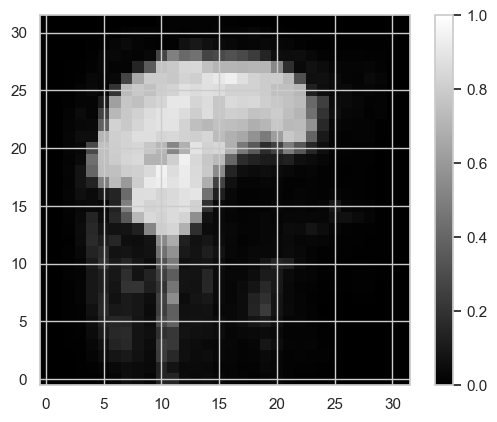

PREDICTED


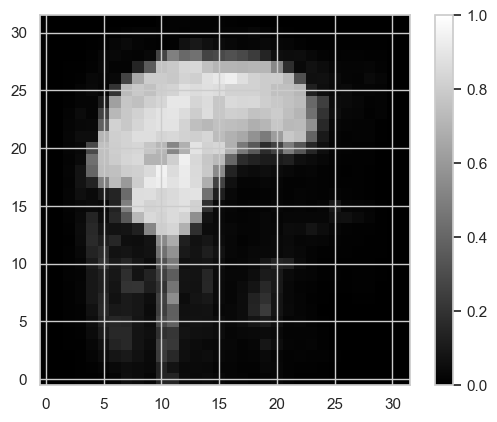

DIFFERENCE


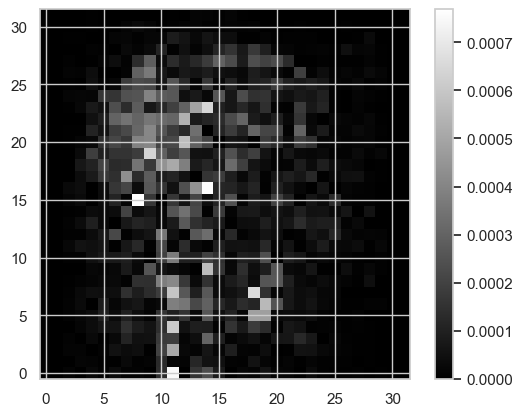

In [18]:
vis = Visualizer(mm_best)
vis.show_scan_slices(scan=37, dim=0, slice=10)

## 12 · Sweep: optimal number of video PCA components

In [42]:
sub = Sub('22')

/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 5 components (34.8% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 5) + audio (9750, 15) → multi (9750, 20)
  video PCA=  5  MSE=2.8962e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 10 components (48.2% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 10) + audio (9750, 15) → multi (9750, 25)
  video PCA= 10  MSE=2.8963e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


...

[Multimodal] Video PCA: 768 → 30 components (70.3% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 30) + audio (9750, 15) → multi (9750, 45)
  video PCA= 30  MSE=2.8940e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 50 components (79.7% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 50) + audio (9750, 15) → multi (9750, 65)
  video PCA= 50  MSE=2.8982e-05


/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/Users/anastasiia/6семестр/m1p/проект/venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


[Multimodal] Video PCA: 768 → 100 components (88.6% variance explained)
[Multimodal] Per-modality StandardScaler applied.
[Multimodal] video (9750, 100) + audio (9750, 15) → multi (9750, 115)
  video PCA=100  MSE=2.9140e-05


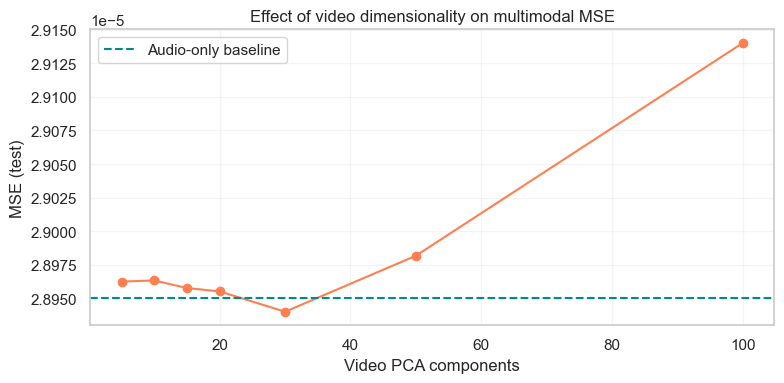

In [43]:
pca_dims = [5, 10, 15, 20, 30, 50, 100]
mse_by_pca = []

for n_pc in pca_dims:
    X_m, X_v, X_a = get_multimodal_encoding(
        video_features=X_video_raw, n_mfcc=15, video_pca=n_pc,
    )
    m = MultimodalLinearDeltaModel(
        vector_list  = X_m, sub=sub, dt=DT, coef=COEF,
        alpha_video  = best_av, alpha_audio = best_aa,
        X_video=X_v, X_audio=X_a, pca_components=None,
    )
    m.fit(); m.predict(); m.evaluate()
    mse_by_pca.append(m.MSE_test)
    print(f"  video PCA={n_pc:3d}  MSE={m.MSE_test:.4e}")

plt.figure(figsize=(8, 4))
plt.plot(pca_dims, mse_by_pca, marker='o', color='coral')
plt.axhline(audio_model.MSE_test, color='darkcyan', linestyle='--', label='Audio-only baseline')
plt.xlabel('Video PCA components')
plt.ylabel('MSE (test)')
plt.title('Effect of video dimensionality on multimodal MSE')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('mse_video_pca_sweep.pdf', bbox_inches='tight')
plt.show()

## 13 · ROI-based analysis: where does video actually help?

The whole-brain MSE hides the true effect of video: it helps **visual cortex**
but adds noise to auditory regions. By computing per-voxel MSE and grouping
voxels by brain region, we can isolate video's contribution.

In [ ]:
audio_model_dt8 = LinearDeltaModel(X_audio_raw, sub, 8, COEF, ALPHA_A)
audio_model_dt8.fit(); audio_model_dt8.predict(); audio_model_dt8.evaluate()

mm_dt8 = MultimodalLinearDeltaModel(
    vector_list=X_multi_15, sub=sub, dt=8, coef=COEF,
    alpha_video=best_av, alpha_audio=best_aa,
    X_video=X_vid_15, X_audio=X_aud_15, pca_components=None,
)
mm_dt8.fit(); mm_dt8.predict(); mm_dt8.evaluate()

err_audio = np.mean(
    (audio_model_dt8.Y_test_predicted - np.delete(audio_model_dt8.Y_test, 0, 1))**2, axis=1
)
err_multi = np.mean(
    (mm_dt8.Y_test_predicted - np.delete(mm_dt8.Y_test, 0, 1))**2, axis=1
)

improvement = err_audio - err_multi

print(f"Total voxels: {len(improvement)}")
print(f"Voxels where multimodal wins: {np.sum(improvement > 0)} "
      f"({np.mean(improvement > 0)*100:.1f}%)")
print(f"Mean improvement: {np.mean(improvement):.2e}")

Total voxels: 20480
Voxels where multimodal wins: 9205 (44.9%)
Mean improvement: 3.48e-08


### 13.1 · Improvement map — which brain regions benefit from video?

/var/folders/7s/1vd48jjd2jb7qjrbhxyml88m0000gn/T/ipykernel_76807/2960731909.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


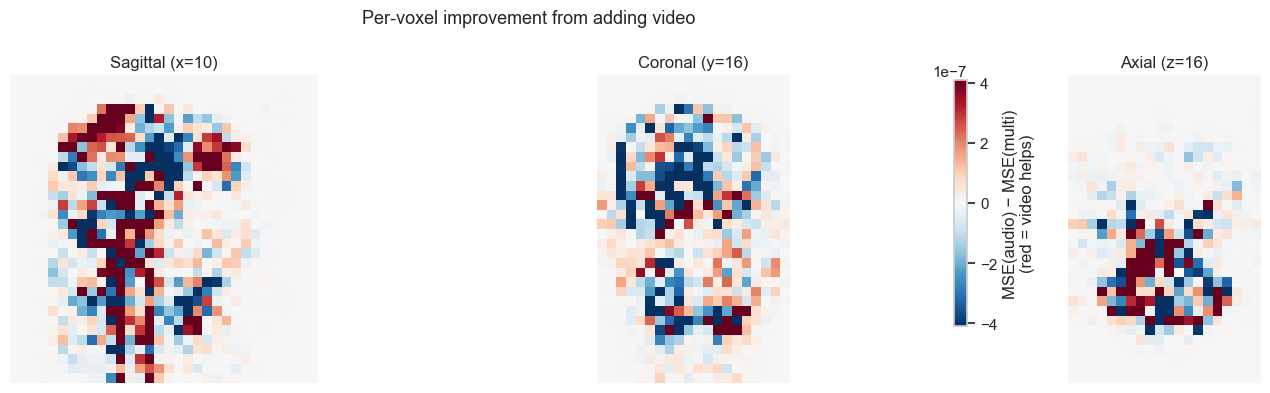

In [ ]:
d1, d2, d3 = mm_dt8._d1, mm_dt8._d2, mm_dt8._d3
imp_3d = improvement.reshape((d1, d2, d3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

slices = [
    (0, d1 // 2, 'Sagittal (x={})'),
    (1, d2 // 2, 'Coronal (y={})'),
    (2, d3 // 2, 'Axial (z={})'),
]

for ax, (dim, sl, title) in zip(axes, slices):
    if dim == 0:
        data = imp_3d[sl, :, :].T
    elif dim == 1:
        data = imp_3d[:, sl, :].T
    else:
        data = imp_3d[:, :, sl].T
    
    vmax = np.percentile(np.abs(improvement), 95)
    im = ax.imshow(data, cmap='RdBu_r', origin='lower',
                   vmin=-vmax, vmax=vmax)
    ax.set_title(title.format(sl))
    ax.axis('off')

plt.colorbar(im, ax=axes, label='MSE(audio) − MSE(multi)\n(red = video helps)',
             shrink=0.8)
plt.suptitle('Per-voxel improvement from adding video', fontsize=13)
plt.tight_layout()
plt.savefig('improvement_map.pdf', bbox_inches='tight')
plt.show()

### 13.2 · Approximate ROI masks

We define simple geometric ROI masks based on typical MNI-space anatomy
in the downsampled volume (after AvgPool with coef=2):
- **Visual cortex (V1/V2)**: posterior slices, lower-middle z
- **Auditory cortex (A1)**: lateral temporal, middle z
- **Frontal**: anterior slices

These are rough approximations.

In [ ]:
d1, d2, d3 = mm_dt8._d1, mm_dt8._d2, mm_dt8._d3
print(f"Downsampled volume: {d1} x {d2} x {d3}")

# Visual cortex: posterior part of the brain
# In typical orientation: low y-indices = posterior
mask_visual = np.zeros((d1, d2, d3), dtype=bool)
mask_visual[:, :d2//4, d3//4:3*d3//4] = True  # posterior quarter, middle z

# Auditory cortex: lateral temporal regions, middle slices
mask_auditory = np.zeros((d1, d2, d3), dtype=bool)
# Superior temporal gyrus — lateral, mid-height
mask_auditory[d1//4:3*d1//4, d2//4:d2//2, d3//3:2*d3//3] = True

# Frontal cortex: anterior
mask_frontal = np.zeros((d1, d2, d3), dtype=bool)
mask_frontal[:, 3*d2//4:, d3//4:3*d3//4] = True

# Whole brain (non-zero voxels)
# Use mean activity to identify brain voxels
brain_mask = np.abs(improvement.reshape(d1, d2, d3)) > 0

masks = {
    'Visual cortex (posterior)': mask_visual & brain_mask,
    'Auditory cortex (temporal)': mask_auditory & brain_mask,
    'Frontal cortex': mask_frontal & brain_mask,
    'Whole brain': brain_mask,
}

for name, mask in masks.items():
    flat_mask = mask.reshape(-1)
    n_vox = flat_mask.sum()
    if n_vox == 0:
        print(f"  {name}: no voxels")
        continue
    
    mse_a = err_audio[flat_mask].mean()
    mse_m = err_multi[flat_mask].mean()
    delta = (mse_a - mse_m) / mse_a * 100
    wins = (improvement[flat_mask] > 0).mean() * 100
    
    print(f"  {name:30s}  n={n_vox:5d}  "
          f"MSE_audio={mse_a:.4e}  MSE_multi={mse_m:.4e}  "
          f"Δ={delta:+.3f}%  wins={wins:.1f}%")

Downsampled volume: 20 x 32 x 32
  Visual cortex (posterior)       n= 1920  MSE_audio=1.3435e-05  MSE_multi=1.3438e-05  Δ=-0.028%  wins=51.4%
  Auditory cortex (temporal)      n=  880  MSE_audio=2.0013e-04  MSE_multi=1.9964e-04  Δ=+0.244%  wins=57.7%
  Frontal cortex                  n= 1920  MSE_audio=2.4487e-06  MSE_multi=2.4541e-06  Δ=-0.221%  wins=50.4%
  Whole brain                     n=17790  MSE_audio=3.2328e-05  MSE_multi=3.2288e-05  Δ=+0.124%  wins=51.7%


### 13.3 · Top-N voxels where video helps most

Top 1000 voxels where video helps most:
  MSE audio:      2.7045e-04
  MSE multimodal: 2.6913e-04
  Improvement:    +0.49%


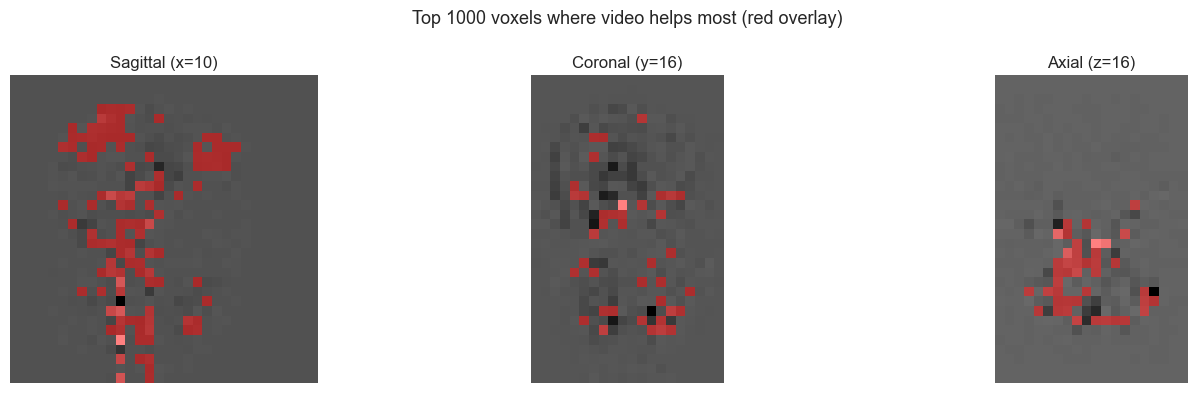

In [ ]:

top_n = 1000
top_idx = np.argsort(improvement)[-top_n:]  

mse_a_top = err_audio[top_idx].mean()
mse_m_top = err_multi[top_idx].mean()
delta_top = (mse_a_top - mse_m_top) / mse_a_top * 100

print(f"Top {top_n} voxels where video helps most:")
print(f"  MSE audio:      {mse_a_top:.4e}")
print(f"  MSE multimodal: {mse_m_top:.4e}")
print(f"  Improvement:    {delta_top:+.2f}%")

top_mask = np.zeros(len(improvement), dtype=bool)
top_mask[top_idx] = True
top_3d = top_mask.reshape(d1, d2, d3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (dim, sl, title) in zip(axes, slices):
    if dim == 0:
        brain_sl = imp_3d[sl, :, :].T
        top_sl = top_3d[sl, :, :].T
    elif dim == 1:
        brain_sl = imp_3d[:, sl, :].T
        top_sl = top_3d[:, sl, :].T
    else:
        brain_sl = imp_3d[:, :, sl].T
        top_sl = top_3d[:, :, sl].T
    
    ax.imshow(brain_sl, cmap='gray', origin='lower')
    from matplotlib import colors as mcolors
    cmap_overlay = mcolors.ListedColormap(['none', 'red'])
    ax.imshow(top_sl.astype(float), cmap=cmap_overlay, origin='lower', alpha=0.5)
    ax.set_title(title.format(sl))
    ax.axis('off')

plt.suptitle(f'Top {top_n} voxels where video helps most (red overlay)', fontsize=13)
plt.tight_layout()
plt.savefig('top_voxels_video_helps.pdf', bbox_inches='tight')
plt.show()

## 14 · Temporal derivatives of video features

BOLD signal reflects *changes* in neural activity. Adding frame-to-frame
differences of video embeddings may capture stimulus transitions better.

In [ ]:
from sklearn.preprocessing import StandardScaler
from dataloader_1 import _resample_to_grid

vid_diff = np.diff(X_vid_15, axis=0, prepend=X_vid_15[:1])
X_vid_aug = np.concatenate([X_vid_15, vid_diff], axis=1) 
X_vid_aug = StandardScaler().fit_transform(X_vid_aug)

X_multi_aug = np.concatenate([X_vid_aug, X_aud_15], axis=1)  
print(f"Augmented multimodal: {X_multi_aug.shape}")


mm_aug = MultimodalLinearDeltaModel(
    vector_list=X_multi_aug, sub=sub, dt=8, coef=COEF,
    alpha_video=best_av, alpha_audio=best_aa,
    X_video=X_vid_aug, X_audio=X_aud_15,
    pca_components=None,
)
mm_aug.fit(); mm_aug.predict(); mm_aug.evaluate()

print(f"\n[Audio-only]           MSE = {audio_model_dt8.MSE_test:.4e}")
print(f"[Multi (no diff)]      MSE = {mm_dt8.MSE_test:.4e}")
print(f"[Multi (+ temp diff)]  MSE = {mm_aug.MSE_test:.4e}")

delta1 = (audio_model_dt8.MSE_test - mm_dt8.MSE_test) / audio_model_dt8.MSE_test * 100
delta2 = (audio_model_dt8.MSE_test - mm_aug.MSE_test) / audio_model_dt8.MSE_test * 100
print(f"\nImprovement without diff: {delta1:+.3f}%")
print(f"Improvement with diff:    {delta2:+.3f}%")

Augmented multimodal: (9750, 75)

[Audio-only]           MSE = 2.8082e-05
[Multi (no diff)]      MSE = 2.8047e-05
[Multi (+ temp diff)]  MSE = 2.8188e-05

Improvement without diff: +0.124%
Improvement with diff:    -0.375%


## 15 · Low-level video features (brightness, contrast, motion)

These 6-dimensional features may better capture what early visual cortex
processes, compared to high-level ViT semantic embeddings.

In [ ]:
from dataloader_1 import get_lowlevel_video_features

ll_raw = get_lowlevel_video_features(
    video_path="src/Film stimulus.mp4",
    cache_path="src/lowlevel_features.npy",
)
print("Low-level shape:", ll_raw.shape)

# Resample and normalise
n_target = int(25.0 * 390.0)
t_target = np.linspace(0.0, 1.0, n_target)
ll_res = StandardScaler().fit_transform(_resample_to_grid(ll_raw, t_target))

# Combine: audio (15) + lowlevel (6) = 21
X_multi_ll = np.concatenate([X_aud_15, ll_res], axis=1)
print(f"Audio + LowLevel: {X_multi_ll.shape}")

# Also try: audio (15) + ViT PCA (15) + lowlevel (6) = 36
X_multi_all = np.concatenate([X_vid_15, ll_res, X_aud_15], axis=1)
print(f"ViT + LowLevel + Audio: {X_multi_all.shape}")

[LowLevel] Saved to src/lowlevel_features.npy
[LowLevel] Extracted (9750, 6) features
Low-level shape: (9750, 6)
Audio + LowLevel: (9750, 21)
ViT + LowLevel + Audio: (9750, 51)


In [ ]:
# Audio + LowLevel only 
mm_ll = MultimodalLinearDeltaModel(
    vector_list=X_multi_ll, sub=sub, dt=8, coef=COEF,
    alpha_video=1e3,   
    alpha_audio=best_aa,
    X_video=ll_res, X_audio=X_aud_15,
    pca_components=None,
)
mm_ll.fit(); mm_ll.predict(); mm_ll.evaluate()

# Audio + ViT + LowLevel
X_vid_plus_ll = np.concatenate([X_vid_15, ll_res], axis=1)
mm_all = MultimodalLinearDeltaModel(
    vector_list=X_multi_all, sub=sub, dt=8, coef=COEF,
    alpha_video=best_av,
    alpha_audio=best_aa,
    X_video=X_vid_plus_ll, X_audio=X_aud_15,
    pca_components=None,
)
mm_all.fit(); mm_all.predict(); mm_all.evaluate()

print(f"{'Model':<35s}  {'MSE':>12s}  {'vs audio':>10s}")
print("-" * 60)
models_comp = [
    ("Audio only", audio_model_dt8.MSE_test),
    ("Audio + ViT(PCA=15)", mm_dt8.MSE_test),
    ("Audio + LowLevel(6d)", mm_ll.MSE_test),
    ("Audio + ViT(PCA=15) + LowLevel", mm_all.MSE_test),
    ("Audio + ViT(PCA=15) + diff", mm_aug.MSE_test),
]
base = audio_model_dt8.MSE_test
for name, mse in models_comp:
    delta = (base - mse) / base * 100
    print(f"  {name:<33s}  {mse:.4e}  {delta:+.3f}%")

Model                                         MSE    vs audio
------------------------------------------------------------
  Audio only                         2.8082e-05  +0.000%
  Audio + ViT(PCA=15)                2.8047e-05  +0.124%
  Audio + LowLevel(6d)               2.8083e-05  -0.004%
  Audio + ViT(PCA=15) + LowLevel     2.8045e-05  +0.134%
  Audio + ViT(PCA=15) + diff         2.8188e-05  -0.375%
